<a href="https://colab.research.google.com/github/doriceambunya/AgriSCO/blob/main/AgriSCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 AgriSCO — Step 1: Setup & Authentication
> Agricultural Space Climate Observatory

**What this notebook does:**
- Installs all required libraries
- Authenticates with Google Earth Engine
- Verifies your setup is working
- Displays your study area on an interactive map

---

## 📦 Step 1.1 — Install Libraries

Run this cell first. It installs `geemap` (GEE in Python) and supporting libraries.

> ⏱️ Takes ~1 minute. You only need to do this once per Colab session.

In [1]:
# Install required libraries
!pip install geemap earthengine-api folium matplotlib pandas geopandas groq -q

print("✅ Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.4 MB/s eta 0:00:00
✅ Libraries installed successfully


## Step 1.2 — Authenticate with Google Earth Engine




In [2]:

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from groq import Groq

# Authenticate
ee.Authenticate()

# Initialize with your GEE project ID

ee.Initialize(project='ee-ambunyadorice')



##  Step 1.3 — Define Study Area (Nakuru, Kenya)

We start with **Nakuru County** — a major maize-growing region in Kenya's Rift Valley.



In [3]:
counties= ee.FeatureCollection('projects/ee-ambunyadorice/assets/counties')
nakuru_roi = counties.filter(ee.Filter.eq('COUNTY_NAM', 'NAKURU'))

# Initialize the Map object first
Map=geemap.Map()

Map.addLayer(
    nakuru_roi,
    {'color': 'FF6600', 'fillColor': 'FF660033'},
    'Nakuru ROI'
)
Map.centerObject(nakuru_roi, 9)
Map.addLayerControl()
Map

Map(center=[-0.4636679800021551, 36.078464001592344], controls=(WidgetControl(options=['position', 'transparen…

# AgriSCO Tool class

In [56]:
class AgriSCO:
    """
    Agricultural Space Climate Observatory
    Detects monthly and annual crop gain/loss using Sentinel-1 SAR.

    """

    def __init__(self, roi, region_name, baseline_years, monitor_year,
                 change_threshold_db=2.5, orbit='ASCENDING'):
        self.roi               = roi
        self.region_name       = region_name
        self.baseline_years    = baseline_years
        self.monitor_year      = monitor_year
        self.change_threshold  = change_threshold_db
        self.orbit             = orbit          # ← stored from init
        self.baseline_monthly  = {}
        self.monitor_monthly   = {}
        self.change_monthly    = {}  # Initialize change_monthly
        self.stats             = []
        print(f"🌍 AgriSCO initialized")
        print(f"   Region:    {region_name}")
        print(f"   Baseline:  {baseline_years[0]}–{baseline_years[-1]}")
        print(f"   Monitor:   {monitor_year}")
        print(f"   Threshold: ±{change_threshold_db} dB")
        print(f"   Orbit:     {orbit}")

    #  S1 monthly composite
    def _s1_composite(self, year, month):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, 'month')
        col = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(self.roi)
            .filterDate(start, end)
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
            .filter(ee.Filter.eq('orbitProperties_pass', self.orbit))
            .select(['VV', 'VH'])
        )
        count = col.size().getInfo()
        if count == 0:
            return None
        return col.mean()

    #  Build baseline
    def build_baseline(self):
        print(f"\n Building baseline ({self.baseline_years[0]}–{self.baseline_years[-1]})...")
        for month in range(1, 13):
            imgs = []
            for year in self.baseline_years:
                img = self._s1_composite(year, month)
                if img is not None:
                    imgs.append(img.select('VH'))
            if imgs:
                self.baseline_monthly[month] = (
                    ee.ImageCollection(imgs).mean().rename('VH_baseline')
                )
                print(f"   Month {month:02d} — {len(imgs)} years averaged")
            else:
                print(f"    Month {month:02d} — no data")
        print(" Baseline complete")

    #  Build monitor year
    def build_monitor(self):
        print(f"\n  Building {self.monitor_year} monthly composites...")
        for month in range(1, 13):
            img = self._s1_composite(self.monitor_year, month)
            if img is not None:
                self.monitor_monthly[month] = img.select('VH').rename('VH_monitor')
                print(f"  Month {month:02d}")
            else:
                print(f"    Month {month:02d} — no data")
        print(" Monitor year complete")

    def detect_changes(self):
        print(f"\n🔍 Detecting changes...")

        # ── Cropland mask ─────────────────────────────────────────
        cropland_mask = (
            ee.ImageCollection('COPERNICUS/Landcover/100m/Proba-V-C3/Global')
            .filterDate('2019-01-01', '2020-01-01')
            .first()
            .select('crops-coverfraction')
            .gt(10)   # pixels where crops cover >30% of area
            .clip(self.roi)
        )

        pixel_area_ha = 100 * 100 / 10000

        for month in range(1, 13):
            if month not in self.baseline_monthly or month not in self.monitor_monthly:
                print(f"  ⚠️  Month {month:02d} — skipped (missing data)")
                continue

            baseline  = self.baseline_monthly[month]
            monitor   = self.monitor_monthly[month]

            # Change in dB — masked to cropland only
            change = (
                monitor.subtract(baseline)
                .rename('change_db')
                .updateMask(cropland_mask)   # ← KEY FIX
            )

            classified = (
                ee.Image(0).rename('class')
                .where(change.lt(-self.change_threshold), 1)   # crop loss
                .where(change.gt(self.change_threshold),  2)   # crop gain
                .updateMask(cropland_mask)                      # ← KEY FIX
            )

            # Store for mapping
            self.change_monthly[month] = {
                'change_db':  change,
                'classified': classified,
                'year':       self.monitor_year,
                'month':      month
            }

            # Quantify
            stats = classified.reduceRegion(
                reducer=ee.Reducer.frequencyHistogram(),
                geometry=self.roi,
                scale=100,
                maxPixels=1e9,
                bestEffort=True
            ).getInfo()

            hist     = stats.get('class', {})
            loss_ha  = round(hist.get('1', 0) * pixel_area_ha, 1)
            gain_ha  = round(hist.get('2', 0) * pixel_area_ha, 1)
            net_ha   = round(gain_ha - loss_ha, 1)

            month_name = ['','Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'][month]

            self.stats.append({
                'month':      month,
                'month_name': month_name,
                'year':       self.monitor_year,
                'loss_ha':    loss_ha,
                'gain_ha':    gain_ha,
                'net_ha':     net_ha
            })

            print(f"  📅 {month_name}: Loss={loss_ha}ha  Gain={gain_ha}ha  Net={net_ha:+.1f}ha")

        print("\n✅ Change detection complete")

    #  Monthly change map
    def map_month(self, month):
        if month not in self.change_monthly:
            print(f"No data for month {month}")
            return

        month_name = pd.Timestamp(f'{self.monitor_year}-{month:02d}-01').strftime('%B %Y')
        classified = self.change_monthly[month]['classified']

        Map = geemap.Map()
        Map.centerObject(self.roi, zoom=9)
        Map.add_basemap('SATELLITE')

        vis = {'min': 0, 'max': 2, 'palette': ['#888888', '#d73027', '#1a9850']}
        Map.addLayer(classified.clip(self.roi), vis, f'Change {month_name}')
        Map.addLayer(ee.Image().paint(self.roi, 0, 3), {'palette': 'white'}, 'Boundary')

        Map.add_legend(
            title=f'AgriSCO — {month_name}',
            legend_dict={
                'Stable':     '#888888',
                'Crop Loss':  '#d73027',
                'Crop Gain':  '#1a9850',
            }
        )
        return Map

    #  Annual change map
    def map_annual(self):
        loss_imgs = []
        gain_imgs = []

        for month, data in self.change_monthly.items():
            c = data['classified']
            loss_imgs.append(c.eq(1))
            gain_imgs.append(c.eq(2))

        # Pixel = loss if loss in ANY month; gain if gain in ANY month
        annual_loss = ee.ImageCollection(loss_imgs).sum().gt(0)
        annual_gain = ee.ImageCollection(gain_imgs).sum().gt(0)

        annual_map = (
            ee.Image(0)
            .where(annual_loss, 1)
            .where(annual_gain, 2)
            .rename('annual_change')
        )

        Map = geemap.Map()
        Map.centerObject(self.roi, zoom=9)
        Map.add_basemap('SATELLITE')

        vis = {'min': 0, 'max': 2, 'palette': ['#888888', '#d73027', '#1a9850']}
        Map.addLayer(annual_map.clip(self.roi), vis, f'Annual Change {self.monitor_year}')
        Map.addLayer(ee.Image().paint(self.roi, 0, 3), {'palette': 'white'}, 'Boundary')

        Map.add_legend(
            title=f'AgriSCO Annual — {self.monitor_year}',
            legend_dict={
                'No change':  '#888888',
                'Crop Loss':  '#d73027',
                'Crop Gain':  '#1a9850',
            }
        )
        return Map

    # ── Time series chart ─────────────────────────────
    def plot_timeseries(self):
        if not self.stats:
            print("Run detect_changes() first")
            return

        df = pd.DataFrame(self.stats)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        x = range(len(df))

        # Gain/Loss bars
        ax1.bar(x, df['gain_ha'], color='#1a9850', alpha=0.8, label='Crop Gain (ha)')
        ax1.bar(x, [-l for l in df['loss_ha']], color='#d73027', alpha=0.8, label='Crop Loss (ha)')
        ax1.axhline(0, color='black', linewidth=0.8)
        ax1.set_ylabel('Area (hectares)')
        ax1.set_title(f'AgriSCO Monthly Crop Change — {self.region_name} {self.monitor_year}')
        ax1.legend()
        ax1.grid(alpha=0.3)

        # Net change line
        colors = ['#1a9850' if n >= 0 else '#d73027' for n in df['net_ha']]
        ax2.bar(x, df['net_ha'], color=colors, alpha=0.8)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_ylabel('Net Change (ha)')
        ax2.set_xlabel('Month')
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(df['month_name'])
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/agrisco_timeseries.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(" Saved to /content/agrisco_timeseries.png")

    #  Summary table ─
    def summary(self):
        if not self.stats:
            print("Run detect_changes() first")
            return

        df = pd.DataFrame(self.stats)
        total_loss = df['loss_ha'].sum()
        total_gain = df['gain_ha'].sum()
        net        = total_gain - total_loss
        worst      = df.loc[df['loss_ha'].idxmax()]
        best       = df.loc[df['gain_ha'].idxmax()]

        print(f"\n{'─'*50}")
        print(f" AgriSCO Annual Summary — {self.region_name} {self.monitor_year}")
        print(f"{'─'*50}")
        print(f"  Total cropland lost:   {total_loss:>10.1f} ha")
        print(f"  Total cropland gained: {total_gain:>10.1f} ha")
        print(f"  Net change:            {net:>+10.1f} ha")
        print(f"  Worst loss month:      {worst['month_name']} ({worst['loss_ha']:.1f} ha)")
        print(f"  Best gain month:       {best['month_name']} ({best['gain_ha']:.1f} ha)")
        print(f"{'─'*50}")
        print(f"\n Monthly breakdown:")
        print(df[['month_name','loss_ha','gain_ha','net_ha']].to_string(index=False))
        return df

    #  LLM Alert
    def generate_alert(self, groq_key):
        if not self.stats:
            print("Run detect_changes() first")
            return

        df      = pd.DataFrame(self.stats)
        total_loss = df['loss_ha'].sum()
        total_gain = df['gain_ha'].sum()
        net        = total_gain - total_loss
        worst      = df.loc[df['loss_ha'].idxmax()]

        prompt = f"""
You are AgriSCO, an agricultural disturbance intelligence system.
Using Sentinel-1 SAR satellite data, you have detected the following
crop changes in {self.region_name} during {self.monitor_year}:

ANNUAL SUMMARY:
- Total cropland lost:   {total_loss:.1f} hectares
- Total cropland gained: {total_gain:.1f} hectares
- Net change:            {net:+.1f} hectares
- Worst loss month:      {worst['month_name']} ({worst['loss_ha']:.1f} ha lost)

MONTHLY DATA:
{df[['month_name','loss_ha','gain_ha','net_ha']].to_string(index=False)}

Generate exactly in this format:
SMS_ALERT_EN: [2 sentences, plain English, for farmers]
SMS_ALERT_SW: [same in Swahili]
FIELD_SUMMARY: [4 sentences, technical, for agronomists and lenders]
RISK_RATING: [High/Medium/Low] — [one sentence explanation]
"""
        client   = Groq(api_key=groq_key)
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )
        alert = response.choices[0].message.content

        print("\n AgriSCO ALERT")
        print("─" * 50)
        print(alert)
        return alert

print("AgriSCO class defined")

AgriSCO class defined


# Initialize

In [57]:
agrisco = AgriSCO(
    roi                 = nakuru_roi,
    region_name         = "Nakuru County, Kenya",
    baseline_years      = [2020, 2021, 2022, 2023],
    monitor_year        = 2025,
    change_threshold_db = 3.5,    # raised slightly
    orbit               = 'ASCENDING'
)

agrisco.build_baseline()

🌍 AgriSCO initialized
   Region:    Nakuru County, Kenya
   Baseline:  2020–2023
   Monitor:   2025
   Threshold: ±3.5 dB
   Orbit:     ASCENDING

 Building baseline (2020–2023)...
   Month 01 — 4 years averaged
   Month 02 — 4 years averaged
   Month 03 — 4 years averaged
   Month 04 — 4 years averaged
   Month 05 — 4 years averaged
   Month 06 — 3 years averaged
   Month 07 — 4 years averaged
   Month 08 — 4 years averaged
   Month 09 — 4 years averaged
   Month 10 — 4 years averaged
   Month 11 — 4 years averaged
   Month 12 — 4 years averaged
 Baseline complete


# Build monitor year

In [58]:
agrisco.build_monitor()


  Building 2025 monthly composites...
  Month 01
  Month 02
  Month 03
  Month 04
  Month 05
  Month 06
  Month 07
  Month 08
  Month 09
  Month 10
  Month 11
  Month 12
 Monitor year complete


# Detect changes

In [59]:
agrisco.detect_changes()


🔍 Detecting changes...
  📅 Jan: Loss=5437.6ha  Gain=7661.4ha  Net=+2223.8ha
  📅 Feb: Loss=6299.6ha  Gain=11958.5ha  Net=+5658.9ha
  📅 Mar: Loss=4276.4ha  Gain=15254.1ha  Net=+10977.7ha
  📅 Apr: Loss=2125.0ha  Gain=33743.0ha  Net=+31618.0ha
  📅 May: Loss=2063.0ha  Gain=4529.2ha  Net=+2466.2ha
  📅 Jun: Loss=3746.9ha  Gain=6641.3ha  Net=+2894.4ha
  📅 Jul: Loss=2505.1ha  Gain=16778.2ha  Net=+14273.1ha
  📅 Aug: Loss=2271.6ha  Gain=13184.8ha  Net=+10913.2ha
  📅 Sep: Loss=3856.9ha  Gain=13676.7ha  Net=+9819.8ha
  📅 Oct: Loss=2313.9ha  Gain=21637.9ha  Net=+19324.0ha
  📅 Nov: Loss=5562.8ha  Gain=5598.6ha  Net=+35.8ha
  📅 Dec: Loss=5901.7ha  Gain=5703.9ha  Net=-197.8ha

✅ Change detection complete


# Visualization


──────────────────────────────────────────────────
 AgriSCO Annual Summary — Nakuru County, Kenya 2025
──────────────────────────────────────────────────
  Total cropland lost:      46360.5 ha
  Total cropland gained:   156367.6 ha
  Net change:             +110007.1 ha
  Worst loss month:      Feb (6299.6 ha)
  Best gain month:       Apr (33743.0 ha)
──────────────────────────────────────────────────

 Monthly breakdown:
month_name  loss_ha  gain_ha  net_ha
       Jan   5437.6   7661.4  2223.8
       Feb   6299.6  11958.5  5658.9
       Mar   4276.4  15254.1 10977.7
       Apr   2125.0  33743.0 31618.0
       May   2063.0   4529.2  2466.2
       Jun   3746.9   6641.3  2894.4
       Jul   2505.1  16778.2 14273.1
       Aug   2271.6  13184.8 10913.2
       Sep   3856.9  13676.7  9819.8
       Oct   2313.9  21637.9 19324.0
       Nov   5562.8   5598.6    35.8
       Dec   5901.7   5703.9  -197.8


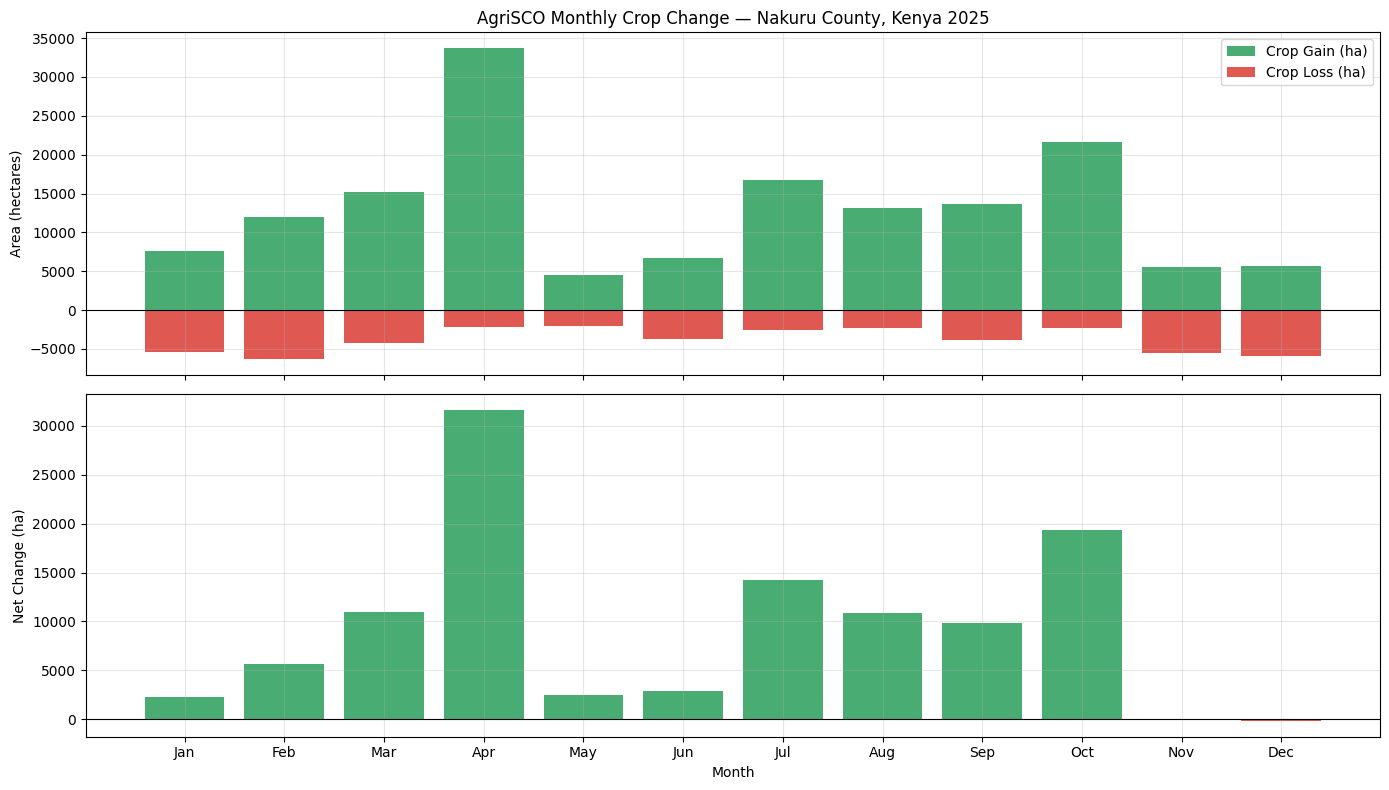

 Saved to /content/agrisco_timeseries.png


Map(center=[-0.4636679800021551, 36.078464001592344], controls=(WidgetControl(options=['position', 'transparen…

In [60]:
# Summary table
agrisco.summary()

# Time series chart
agrisco.plot_timeseries()

# Monthly map — change any month number (1–12)
agrisco.map_month(6)   # June

# Annual map


In [61]:
agrisco.map_annual()



Map(center=[-0.4636679800021551, 36.078464001592344], controls=(WidgetControl(options=['position', 'transparen…

# Aleart

In [62]:
from google.colab import userdata

# Retrieve your Groq API key from Colab secrets
GROQ_API_KEY = userdata.get('AgriSCO') # Use the name you gave your secret

agrisco.generate_alert(groq_key=GROQ_API_KEY)


 AgriSCO ALERT
──────────────────────────────────────────────────
SMS_ALERT_EN:
Nakuru County farmers, be aware that a net gain of 110,007 hectares of cropland was observed in 2025, with April experiencing the highest net gain of 31,618 hectares.

SMS_ALERT_SW:
Wakulima wa Kaunti ya Nakuru, ondoa kwa uangalia kwamba jumla ya kilomètre za ardhi mbalimbali ziliongezwa kwa 110,007 katika 2025, na Aprili kuwa na ongezeko kubwa zaidi la kilom 31,618.

FIELD_SUMMARY:
The annual net gain of 110,007 hectares of cropland in Nakuru County, Kenya during 2025 indicates a significant expansion of agricultural land use. The highest net gain was observed in April with 31,618 hectares, while February experienced the worst loss of 6,299.6 hectares. The cropland gain in July and August was largely due to the expansion of maize and bean crops, respectively. The high net gain in April could be attributed to the timely planting of crops during the long rains season.

RISK_RATING: High — The high net gain 

'SMS_ALERT_EN:\nNakuru County farmers, be aware that a net gain of 110,007 hectares of cropland was observed in 2025, with April experiencing the highest net gain of 31,618 hectares.\n\nSMS_ALERT_SW:\nWakulima wa Kaunti ya Nakuru, ondoa kwa uangalia kwamba jumla ya kilomètre za ardhi mbalimbali ziliongezwa kwa 110,007 katika 2025, na Aprili kuwa na ongezeko kubwa zaidi la kilom 31,618.\n\nFIELD_SUMMARY:\nThe annual net gain of 110,007 hectares of cropland in Nakuru County, Kenya during 2025 indicates a significant expansion of agricultural land use. The highest net gain was observed in April with 31,618 hectares, while February experienced the worst loss of 6,299.6 hectares. The cropland gain in July and August was largely due to the expansion of maize and bean crops, respectively. The high net gain in April could be attributed to the timely planting of crops during the long rains season.\n\nRISK_RATING: High — The high net gain of cropland in Nakuru County, Kenya during 2025 may mask 